### Task 5 - Model Iteration - BERT model 2


Importing all libraries that we will need to exxecute the code and run the model properly: 

In [5]:
import pandas as pd
import re
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
from collections import Counter

In [ ]:
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AdamW,
    get_scheduler,
)
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm


# loading and cleaning the dataset
df = pd.read_csv("final_filtered_dataset.csv", encoding="latin1")
df = df.dropna(subset=["Corrected Sentence", "Corrected_Emotion"])
df = df.drop_duplicates(subset=["Corrected Sentence", "Corrected_Emotion"])

# balancing the dataset
emotion_counts = df["Corrected_Emotion"].value_counts()
max_count = emotion_counts.max()
df_balanced = pd.concat(
    [
        resample(
            df[df["Corrected_Emotion"] == label],
            replace=True,
            n_samples=max_count,
            random_state=42,
        )
        for label in emotion_counts.index
    ]
)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


# labeling encoding

label_encoder = LabelEncoder()
df_balanced["label"] = label_encoder.fit_transform(df_balanced["Corrected_Emotion"])


# tokenizing sentences

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
encodings = tokenizer(
    list(df_balanced["Corrected Sentence"]),
    truncation=True,
    padding=True,
    return_tensors="pt",
)
labels = torch.tensor(df_balanced["label"].values, dtype=torch.long)


# training test split

train_idx, test_idx = train_test_split(
    list(range(len(df_balanced))),
    test_size=0.2,
    stratify=df_balanced["label"],
    random_state=42,
)
train_encodings = {k: v[train_idx] for k, v in encodings.items()}
test_encodings = {k: v[test_idx] for k, v in encodings.items()}
train_labels = labels[train_idx]
test_labels = labels[test_idx]


# custom dataset

class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = EmotionDataset(train_encodings, train_labels)
test_dataset = EmotionDataset(test_encodings, test_labels)


# setingup model and training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=len(label_encoder.classes_)
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
num_training_steps = len(train_loader) * 4
lr_scheduler = get_scheduler(
    "linear", optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)


# training loop

model.train()
for epoch in range(4):
    print(f"\nEpoch {epoch+1}/4")
    loop = tqdm(train_loader)
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

print("\n✅ Training complete!")

d:\anaconda\envs\block_c_y2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda\envs\block_c_y2\lib\site-packages\IPython\core\interactiveshell.py:3508: DtypeWarning: Columns (8,17,18,19,20,21,22,23,24,25) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\anaconda\envs\block_c_y2\lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorc


Epoch 1/4


Epoch 1: 100%|██████████| 682/682 [17:00<00:00,  1.50s/it, loss=0.501] 



Epoch 2/4


Epoch 2: 100%|██████████| 682/682 [16:58<00:00,  1.49s/it, loss=0.0426]



Epoch 3/4


Epoch 3: 100%|██████████| 682/682 [16:53<00:00,  1.49s/it, loss=0.0472] 



Epoch 4/4


Epoch 4: 100%|██████████| 682/682 [16:53<00:00,  1.49s/it, loss=0.0065] 


✅ Training complete!


##### Evaluation of the model

In [2]:
from sklearn.metrics import accuracy_score

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

acc = accuracy_score(true_labels, predictions)
print(f"\n🧪 Test Accuracy: {acc:.4f}")


🧪 Test Accuracy: 0.9677


Further evaluation of the model: 


📊 Model Evaluation Metrics:
Accuracy  : 0.9677
Precision : 0.9677
Recall    : 0.9677
F1-score  : 0.9672

🔍 Classification Report:
              precision    recall  f1-score   support

       anger       0.98      0.99      0.99       389
     disgust       0.98      1.00      0.99       389
        fear       0.98      0.99      0.98       390
   happiness       0.94      0.95      0.95       390
     neutral       0.96      0.86      0.91       390
     sadness       0.98      1.00      0.99       390
    surprise       0.95      0.98      0.97       390

    accuracy                           0.97      2728
   macro avg       0.97      0.97      0.97      2728
weighted avg       0.97      0.97      0.97      2728

🧩 Confusion Matrix:
[[386   3   0   0   0   0   0]
 [  0 389   0   0   0   0   0]
 [  0   3 385   0   0   0   2]
 [  1   0   0 370  12   0   7]
 [  7   0   4  22 336   9  12]
 [  0   0   0   0   0 390   0]
 [  0   1   4   0   1   0 384]]


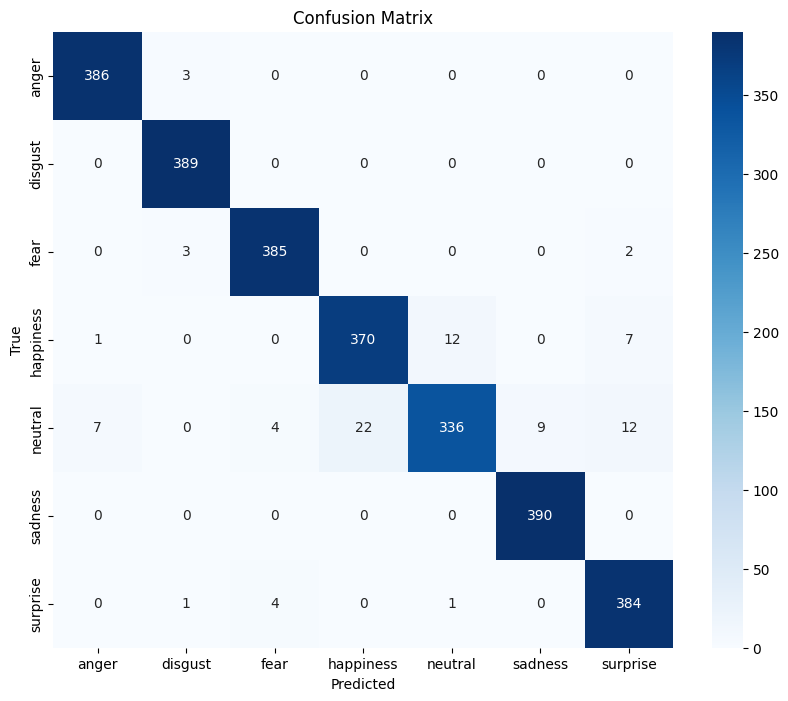

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import numpy as np

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels)

#convering to numpy arrays
y_pred = np.array(predictions)
y_true = np.array(true_labels)

#listing all he metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

#printing overall metrics
print("\n📊 Model Evaluation Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

#printing full classification report
class_names = label_encoder.classes_
print("\n🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

#display of the confusion matrix
print("🧩 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Saving the model: 

In [7]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model.save_pretrained("emotion_model_BERT4")
tokenizer.save_pretrained("emotion_model_BERT4_tokenizer")

('emotion_model_BERT4_tokenizer\\tokenizer_config.json',
 'emotion_model_BERT4_tokenizer\\special_tokens_map.json',
 'emotion_model_BERT4_tokenizer\\vocab.txt',
 'emotion_model_BERT4_tokenizer\\added_tokens.json')